# Time to slice and dice

Most of the time, the data you work with won’t be perfectly prepared for training models. In this section we’ll explore the various features that 🤗 Datasets provides to clean up your datasets.

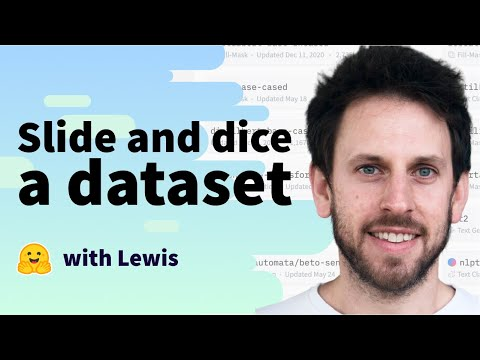

In [1]:
from IPython.display import YouTubeVideo

YouTubeVideo("tqfSFcPMgOI", width=800, height=450)

## Slicing and dicing our data

Similar to Pandas, 🤗 Datasets provides several functions to manipulate the contents of `Dataset` and `DatasetDict` objects. We already encountered the `Dataset.map()` method in [Chapter 3](https://huggingface.co/course/chapter3), and in this section we’ll explore some of the other functions at our disposal.

For this example we’ll use the [Drug Review Dataset](https://archive.ics.uci.edu/ml/datasets/Drug+Review+Dataset+%28Drugs.com%29) that’s hosted on the [UC Irvine Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php), which contains patient reviews on various drugs, along with the condition being treated and a 10-star rating of the patient’s satisfaction.

First we need to download and extract the data, which can be done with the `wget` and `unzip` commands:

In [2]:
!rm ./drugsCom*
!wget -qq "https://archive.ics.uci.edu/ml/machine-learning-databases/00462/drugsCom_raw.zip" --show-progress
!unzip drugsCom_raw.zip

drugsCom_raw.zip        [              <=>   ]  41.00M  1.58MB/s    in 47s     
Archive:  drugsCom_raw.zip
  inflating: drugsComTest_raw.tsv    
  inflating: drugsComTrain_raw.tsv   


---

Since TSV is just a variant of CSV that uses tabs instead of commas as the separator, we can load these files by using the `csv` loading script and specifying the `delimiter` argument in the `load_dataset()` function as follows:

In [3]:
from datasets import load_dataset

data_files = {
    "train": "drugsComTrain_raw.tsv", 
    "test": "drugsComTest_raw.tsv"
}

drug_dataset = load_dataset("csv", data_files=data_files, delimiter="\t")

---

A good practice when doing any sort of data analysis is to grab a small random sample to get a quick feel for the type of data you’re working with. In 🤗 Datasets, we can create a random sample by chaining the `Dataset.shuffle()` and `Dataset.select()` functions together:

In [4]:
drug_sample = drug_dataset["train"].shuffle(seed=42).select(range(1000))

for k, varr in drug_sample[0:3].items():
    print(f"`{k}`:")
    for v in varr:
        print(f" - {v}")
    print()

`Unnamed: 0`:
 - 87571
 - 178045
 - 80482

`drugName`:
 - Naproxen
 - Duloxetine
 - Mobic

`condition`:
 - Gout, Acute
 - ibromyalgia
 - Inflammatory Conditions

`review`:
 - "like the previous person mention, I&#039;m a strong believer of aleve, it works faster for my gout than the prescription meds I take. No more going to the doctor for refills.....Aleve works!"
 - "I have taken Cymbalta for about a year and a half for fibromyalgia pain. It is great
as a pain reducer and an anti-depressant, however, the side effects outweighed 
any benefit I got from it. I had trouble with restlessness, being tired constantly,
dizziness, dry mouth, numbness and tingling in my feet, and horrible sweating. I am
being weaned off of it now. Went from 60 mg to 30mg and now to 15 mg. I will be
off completely in about a week. The fibro pain is coming back, but I would rather deal with it than the side effects."
 - "I have been taking Mobic for over a year with no side effects other than an elevated blood p

---

Note that we’ve fixed the seed in `Dataset.shuffle()` for reproducibility purposes. `Dataset.select()` expects an iterable of indices, so we’ve passed `range(1000)` to grab the first 1,000 examples from the shuffled dataset. From this sample we can already see a few quirks in our dataset:

- The `Unnamed: 0` column looks suspiciously like an anonymized ID for each patient.
- The `condition` column includes a mix of uppercase and lowercase labels.
- The reviews are of varying length and contain a mix of Python line separators ("`\r\n`") as well as HTML character codes like "`&\#039;`".

Let’s see how we can use 🤗 Datasets to deal with each of these issues. To test the patient ID hypothesis for the Unnamed: 0 column, we can use the Dataset.unique() function to verify that the number of IDs matches the number of rows in each split:

In [5]:
for split in drug_dataset.keys():
    assert len(drug_dataset[split]) == len(drug_dataset[split].unique("Unnamed: 0"))

---

This seems to confirm our hypothesis, so let’s clean up the dataset a bit by renaming the Unnamed: 0 column to something a bit more interpretable. We can use the DatasetDict.rename_column() function to rename the column across both splits in one go:

In [6]:
drug_dataset = drug_dataset.rename_column(
    original_column_name="Unnamed: 0", 
    new_column_name="patient_id"
)

drug_dataset

DatasetDict({
    train: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount'],
        num_rows: 161297
    })
    test: Dataset({
        features: ['patient_id', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount'],
        num_rows: 53766
    })
})

> ✏️ Try it out! Use the `Dataset.unique()` function to find the number of unique drugs and conditions in the training and test sets.

In [7]:
ud = len(drug_dataset['train'].unique("drugName"))
uc = len(drug_dataset['train'].unique("condition"))

ud, uc

(3436, 885)

Next, let’s normalize all the `condition` labels using `Dataset.map()`. As we did with tokenization in [Chapter 3](https://huggingface.co/course/chapter3), we can define a simple function that can be applied across all the rows of each split in drug_dataset:

In [8]:
drug_dataset = drug_dataset.filter(lambda x: x['condition'])

> NOTE: note that the returned dictionary only contains single key which needs to be modified.

In [9]:
drug_dataset = drug_dataset.map(lambda x: {"condition": x["condition"].lower()})

In [10]:
drug_dataset["train"]["condition"][:3]

['left ventricular dysfunction', 'adhd', 'birth control']

It works! Now that we’ve cleaned up the labels, let’s take a look at cleaning up the reviews themselves.

## Creating new columns

Whenever you’re dealing with customer reviews, a good practice is to check the number of words in each review. A review might be just a single word like “Great!” or a full-blown essay with thousands of words, and depending on the use case you’ll need to handle these extremes differently. To compute the number of words in each review, we’ll use a rough heuristic based on splitting each text by whitespace.

Let’s define a simple function that counts the number of words in each review:

> Similar to lower case map function like above, new column which needs to be created can also be returned. It will not affect the other keys.

In [11]:
drug_dataset = drug_dataset.map(lambda x: {'review_length': len(x['review'].split())})
drug_dataset["train"][0]

{'patient_id': 206461,
 'drugName': 'Valsartan',
 'condition': 'left ventricular dysfunction',
 'review': '"It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil"',
 'rating': 9.0,
 'date': 'May 20, 2012',
 'usefulCount': 27,
 'review_length': 17}

As expected, we can see a `review_length` column has been added to our training set. We can sort this new column with `Dataset.sort()` to see what the extreme values look like:

In [12]:
drug_dataset["train"].sort(column_names="review_length")[:3]

{'patient_id': [111469, 13653, 53602],
 'drugName': ['Ledipasvir / sofosbuvir',
  'Amphetamine / dextroamphetamine',
  'Alesse'],
 'condition': ['hepatitis c', 'adhd', 'birth control'],
 'review': ['"Headache"', '"Great"', '"Awesome"'],
 'rating': [10.0, 10.0, 10.0],
 'date': ['February 3, 2015', 'October 20, 2009', 'November 23, 2015'],
 'usefulCount': [41, 3, 0],
 'review_length': [1, 1, 1]}

---

As we suspected, some reviews contain just a single word, which, although it may be okay for sentiment analysis, would not be informative if we want to predict the condition.

> 🙋 An alternative way to add new columns to a dataset is with the `Dataset.add_column()` function. This allows you to provide the column as a Python list or NumPy array and can be handy in situations where `Dataset.map()` is not well suited for your analysis.

Let’s use the `Dataset.filter()` function to remove reviews that contain fewer than 30 words. Similarly to what we did with the condition column, we can filter out the very short reviews by requiring that the reviews have a length above this threshold:

In [13]:
drug_dataset = drug_dataset.filter(lambda x: x["review_length"] > 30)
drug_dataset.num_rows

{'train': 138514, 'test': 46108}

As you can see, this has removed around 15% of the reviews from our original training and test sets.

> ✏️ Try it out! Use the `Dataset.sort()` function to inspect the reviews with the largest numbers of words. See the [documentation](https://huggingface.co/docs/datasets/package_reference/main_classes#datasets.Dataset.sort) to see which argument you need to use sort the reviews by length in descending order.

---

The last thing we need to deal with is the presence of HTML character codes in our reviews. We can use Python’s html module to unescape these characters, like so:

In [14]:
import html

text = "I&#039;m a transformer called BERT"
html.unescape(text)

"I'm a transformer called BERT"

We’ll use `Dataset.map()` to unescape all the HTML characters in our corpus:

In [15]:
drug_dataset = drug_dataset.map(lambda x: {"review": html.unescape(x["review"])})

---

As you can see, the `Dataset.map()` method is quite useful for processing data — and we haven’t even scratched the surface of everything it can do!

## The map() method’s superpowers

The `Dataset.map()` method takes a batched argument that, if set to `True`, causes it to send a batch of examples to the map function at once (the batch size is configurable but defaults to 1,000). For instance, the previous map function that unescaped all the HTML took a bit of time to run (you can read the time taken from the progress bars). We can speed this up by processing several elements at the same time using a list comprehension.

When you specify `batched=True` the function receives a dictionary with the fields of the dataset, but each value is now a list of values, and not just a single value. The return value of `Dataset.map()` should be the same: a dictionary with the fields we want to update or add to our dataset, and a list of values. For example, here is another way to unescape all HTML characters, but using `batched=True`:

In [16]:
new_drug_dataset = drug_dataset.map(
    function=lambda x: {"review": [html.unescape(o) for o in x["review"]]}, batched=True
)

If you’re running this code in a notebook, you’ll see that this command executes way faster than the previous one. And it’s not because our reviews have already been HTML-unescaped — if you re-execute the instruction from the previous section (without `batched=True`), it will take the same amount of time as before. This is because list comprehensions are usually faster than executing the same code in a `for` loop, and we also gain some performance by accessing lots of elements at the same time instead of one by one.

Using `Dataset.map()` with `batched=True` will be essential to unlock the speed of the “fast” tokenizers that we’ll encounter in [Chapter 6](https://huggingface.co/course/chapter6), which can quickly tokenize big lists of texts. For instance, to tokenize all the drug reviews with a fast tokenizer, we could use a function like this:

In [17]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")


def tokenize_function(examples):
    return tokenizer(examples["review"], truncation=True)

---

As you saw in [Chapter 3](https://huggingface.co/course/chapter3), we can pass one or several examples to the tokenizer, so we can use this function with or without `batched=True`. Let’s take this opportunity to compare the performance of the different options. In a notebook, you can time a one-line instruction by adding `%time` before the line of code you wish to measure:

In [18]:
%time tokenized_dataset = drug_dataset.map(tokenize_function, batched=True)

CPU times: user 145 ms, sys: 23.4 ms, total: 168 ms
Wall time: 320 ms


---

You can also time a whole cell by putting %%time at the beginning of the cell. On the hardware we executed this on, it showed 10.8s for this instruction (it’s the number written after “Wall time”).

> ✏️ Try it out! Execute the same instruction with and without `batched=True`, then try it with a slow tokenizer (add `use_fast=False` in the AutoTokenizer.from_pretrained() method) so you can see what numbers you get on your hardware.

Here are the results we obtained with and without batching, with a fast and a slow tokenizer:

|Options|Fast tokenizer|Slow tokenizer|
|---|---|---|
|`batched=True`|10.8s|4min41s|
|`batched=False`|59.2s|5min3s|

This means that using a fast tokenizer with the `batched=True` option is 30 times faster than its slow counterpart with no batching — this is truly amazing! That’s the main reason why fast tokenizers are the default when using `AutoTokenizer` (and why they are called “fast”). They’re able to achieve such a speedup because behind the scenes the tokenization code is executed in Rust, which is a language that makes it easy to parallelize code execution.

Parallelization is also the reason for the nearly 6x speedup the fast tokenizer achieves with batching: you can’t parallelize a single tokenization operation, but when you want to tokenize lots of texts at the same time you can just split the execution across several processes, each responsible for its own texts.

`Dataset.map()` also has some parallelization capabilities of its own. Since they are not backed by Rust, they won’t let a slow `tokenizer` catch up with a fast one, but they can still be helpful (especially if you’re using a tokenizer that doesn’t have a fast version). To enable multiprocessing, use the `num_proc` argument and specify the number of processes to use in your call to `Dataset.map()`:

In [19]:
slow_tokenizer = AutoTokenizer.from_pretrained("bert-base-cased", use_fast=False)

tokenized_dataset = drug_dataset.map(
    function=lambda x: slow_tokenizer(x["review"], truncation=True), 
    batched=True, 
    num_proc=8
)

You can experiment a little with timing to determine the optimal number of processes to use; in our case 8 seemed to produce the best speed gain. Here are the numbers we got with and without multiprocessing:

|Options|Fast tokenizer|Slow tokenizer|
|---|---|---|
|batched=True|10.8s|4min41s|
|batched=False|59.2s|5min3s|
|batched=True, num_proc=8|6.52s|41.3s|
|batched=False, num_proc=8|9.49s|45.2s|